# ISA Mini-Project 1 – Exploratory Data Analysis
## Spotify Million Playlist Dataset

This notebook performs EDA on the parquet files produced by the two-stage data pipeline:

1. `ingest.py` — converts MPD JSON slices into three normalized parquet files:
   - `playlists.parquet` — one row per playlist (full metadata)
   - `tracks.parquet` — one row per (playlist, track) entry, ordered by position
   - `track_meta.parquet` — deduplicated track catalog (one row per unique `track_uri`)

2. `preprocess.py` — builds vocabulary and encodes sequences for modeling:
   - `track_vocab.parquet` — vocabulary: `track_uri`, `corpus_idx` (0 = most frequent), `corpus_freq`
   - `train_seqs.parquet`, `val_seqs.parquet`, `test_seqs.parquet` — integer-encoded sequences with stratified train/val/test split

Run both scripts before executing this notebook:
```bash
MPD_PATH=./data/mpd/data python src/ingest.py
python src/preprocess.py
```

---
## 0. Setup

In [1]:
import os
import re
import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

PROCESSED = Path('../processed')
OUT       = Path('outputs')
OUT.mkdir(exist_ok=True)

# ── ingest.py outputs ────────────────────────────────────────────────────────
pls        = pd.read_parquet(PROCESSED / 'playlists.parquet')
trks       = pd.read_parquet(PROCESSED / 'tracks.parquet')
track_meta = pd.read_parquet(PROCESSED / 'track_meta.parquet')

print('=== ingest.py outputs ===')
print(f'playlists.parquet  : {len(pls):>10,} rows')
print(f'tracks.parquet     : {len(trks):>10,} rows')
print(f'track_meta.parquet : {len(track_meta):>10,} unique tracks')

# ── preprocess.py outputs ────────────────────────────────────────────────────
vocab      = pd.read_parquet(PROCESSED / 'track_vocab.parquet')
train_seqs = pd.read_parquet(PROCESSED / 'train_seqs.parquet')
val_seqs   = pd.read_parquet(PROCESSED / 'val_seqs.parquet')
test_seqs  = pd.read_parquet(PROCESSED / 'test_seqs.parquet')

print()
print('=== preprocess.py outputs ===')
print(f'track_vocab.parquet : {len(vocab):>10,} unique tracks in vocabulary')
total_seqs = len(train_seqs) + len(val_seqs) + len(test_seqs)
print(f'train_seqs.parquet  : {len(train_seqs):>10,} sequences  ({len(train_seqs)/total_seqs*100:.1f}%)')
print(f'val_seqs.parquet    : {len(val_seqs):>10,} sequences  ({len(val_seqs)/total_seqs*100:.1f}%)')
print(f'test_seqs.parquet   : {len(test_seqs):>10,} sequences  ({len(test_seqs)/total_seqs*100:.1f}%)')

=== ingest.py outputs ===
playlists.parquet  :  1,000,000 rows
tracks.parquet     : 66,346,428 rows
track_meta.parquet :  2,262,292 unique tracks

=== preprocess.py outputs ===
track_vocab.parquet :  2,262,292 unique tracks in vocabulary
train_seqs.parquet  :    799,998 sequences  (80.0%)
val_seqs.parquet    :    100,001 sequences  (10.0%)
test_seqs.parquet   :    100,001 sequences  (10.0%)


---
## 1. Dataset Overview

In [2]:
print('=== Playlists ===')
print(f'  Total playlists  : {len(pls):,}')
print(f'  With description : {pls["has_desc"].sum():,}  ({pls["has_desc"].mean()*100:.1f}%)')
print(f'  Collaborative    : {(pls["collaborative"]=="true").sum():,}  ({(pls["collaborative"]=="true").mean()*100:.2f}%)')
print()
print('=== Tracks ===')
print(f'  Total track entries : {len(trks):,}')
print(f'  Unique tracks       : {len(track_meta):,}')
print(f'  Unique artists      : {trks["artist_uri"].nunique():,}')
print(f'  Unique albums       : {trks["album_uri"].nunique():,}')

=== Playlists ===
  Total playlists  : 1,000,000
  With description : 18,760  (1.9%)
  Collaborative    : 22,569  (2.26%)

=== Tracks ===
  Total track entries : 66,346,428
  Unique tracks       : 2,262,292
  Unique artists      : 295,860
  Unique albums       : 734,684


---
## 2. Playlist-level Statistics

### 2.1 Trimmed summary statistics (10th – 90th percentile)

Outliers are excluded using the 10th and 90th percentile thresholds to get more representative central tendency measures.

In [3]:
TRIM_LO, TRIM_HI = 0.10, 0.90
stat_cols = ['num_tracks', 'num_artists', 'num_albums', 'num_followers', 'num_edits', 'duration_ms']

rows = []
for col in stat_cols:
    lo = pls[col].quantile(TRIM_LO)
    hi = pls[col].quantile(TRIM_HI)
    trimmed = pls[(pls[col] >= lo) & (pls[col] <= hi)][col]
    rows.append({
        'variable':        col,
        'trimmed_median':  round(trimmed.median(), 2),
        'trimmed_mean':    round(trimmed.mean(), 2),
        'trimmed_std':     round(trimmed.std(), 2),
        'p10':             round(lo, 2),
        'p90':             round(hi, 2),
    })

stats_df = pd.DataFrame(rows).set_index('variable')
stats_df

,trimmed_median,trimmed_mean,trimmed_std,p10,p90
variable,,,,,
num_tracks,49.0,57.88,34.41,15.0,148.0
num_artists,29.0,33.47,18.45,9.0,80.0
num_albums,37.0,42.93,25.13,11.0,108.0
num_followers,1.0,1.17,0.37,1.0,2.0
num_edits,10.0,13.27,10.07,3.0,43.0
duration_ms,11422438.0,13562195.05,8057159.73,3444330.7,34750508.9


### 2.2 Distribution of playlist lengths

This histogram shows the distribution of the number of tracks per playlist. 

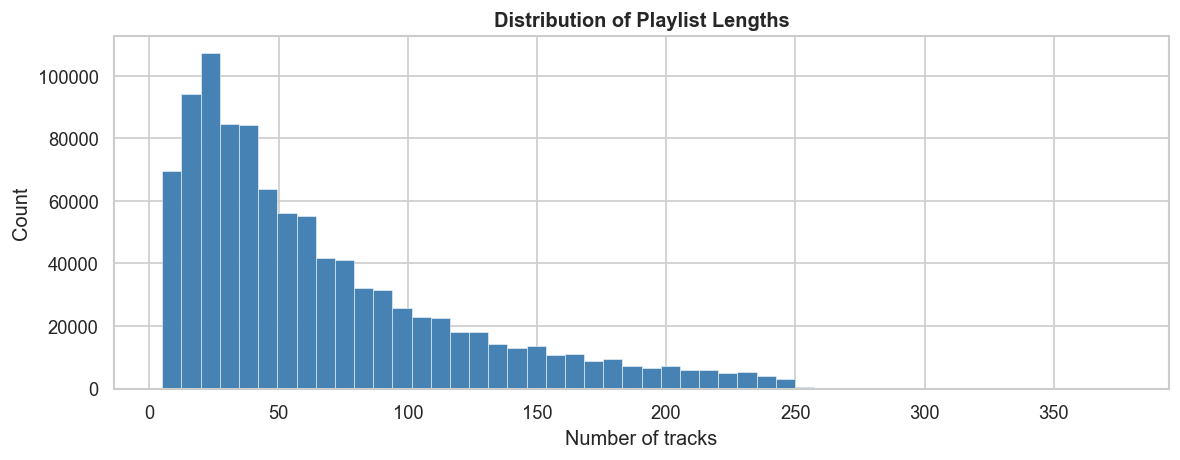

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(pls['num_tracks'], bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_title('Distribution of Playlist Lengths', fontweight='bold')
ax.set_xlabel('Number of tracks')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(OUT / 'eda_playlist_lengths.png', bbox_inches='tight')
plt.show()

The distribution is right-skewed with a peak around 20–30 tracks and a long tail extending to the maximum of 250 tracks. This tells us most users create relatively short playlists, which informs how we size the seed and holdout portions during evaluation.

### 2.3 Correlation heatmap of playlist features

This heatmap shows the pairwise correlations between all six playlist-level features. It is used to identify redundant features before modeling.

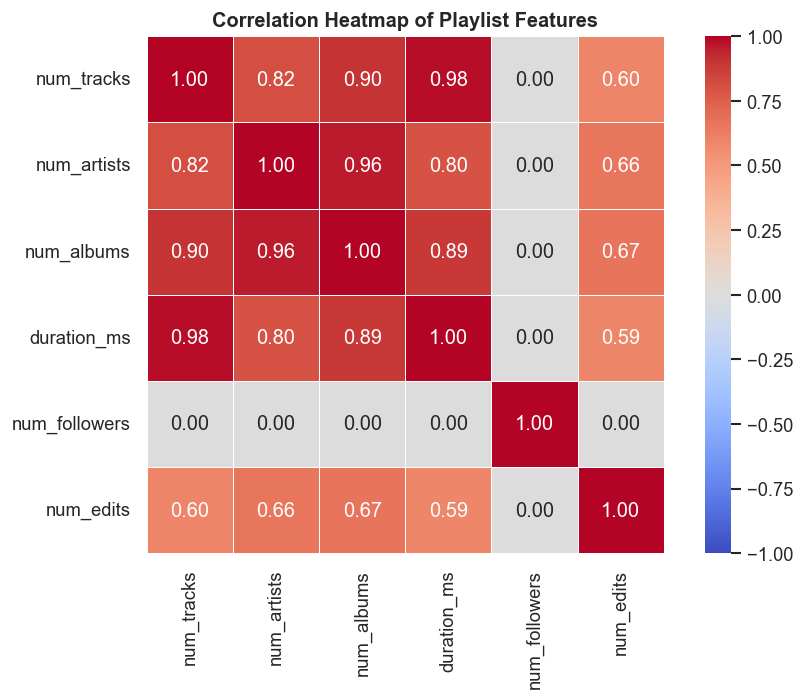

In [5]:
corr_cols = ['num_tracks', 'num_artists', 'num_albums', 'duration_ms', 'num_followers', 'num_edits']
corr = pls[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax
)
ax.set_title('Correlation Heatmap of Playlist Features', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'eda_correlation_heatmap.png', bbox_inches='tight')
plt.show()

### 2.4 Feature selection justification

Based on the correlation heatmap, the following conclusions are drawn about which playlist-level features are useful for a recommender system:

- **`num_tracks`, `num_artists`, `num_albums`, `duration_ms`** are all strongly correlated (r ≥ 0.80). They are largely redundant — `num_tracks` alone is sufficient as a proxy for playlist size.
- **`num_followers`** has near-zero correlation with every other feature (r ≈ 0.00). It carries no information about playlist composition and is not useful for recommendation. Its distribution (nearly all playlists have 1 follower) confirms this — it is essentially a constant.
- **`num_edits`** has moderate correlation with size features (r ≈ 0.60–0.67), meaning longer playlists were built over more sessions. It adds no independent signal beyond `num_tracks`.

**Conclusion:** Of the six playlist-level features, only `num_tracks` is retained for modeling. `num_followers` and `num_edits` are dropped as uninformative for track recommendation.

---
## 3. Track-level Analysis

### 3.1 Track and artist summary statistics

In [6]:
avg_dur = trks['track_dur_ms'].mean() / 1000
print('Songs summary')
print(f'  Average track duration : {avg_dur:.1f}s  ({avg_dur/60:.2f} min)')
print(f'  Unique artists         : {trks["artist_uri"].nunique():,}')
print(f'  Unique albums          : {trks["album_uri"].nunique():,}')

Songs summary
  Average track duration : 234.8s  (3.91 min)
  Unique artists         : 295,860
  Unique albums          : 734,684


### 3.2 Top 10 artists by number of tracks

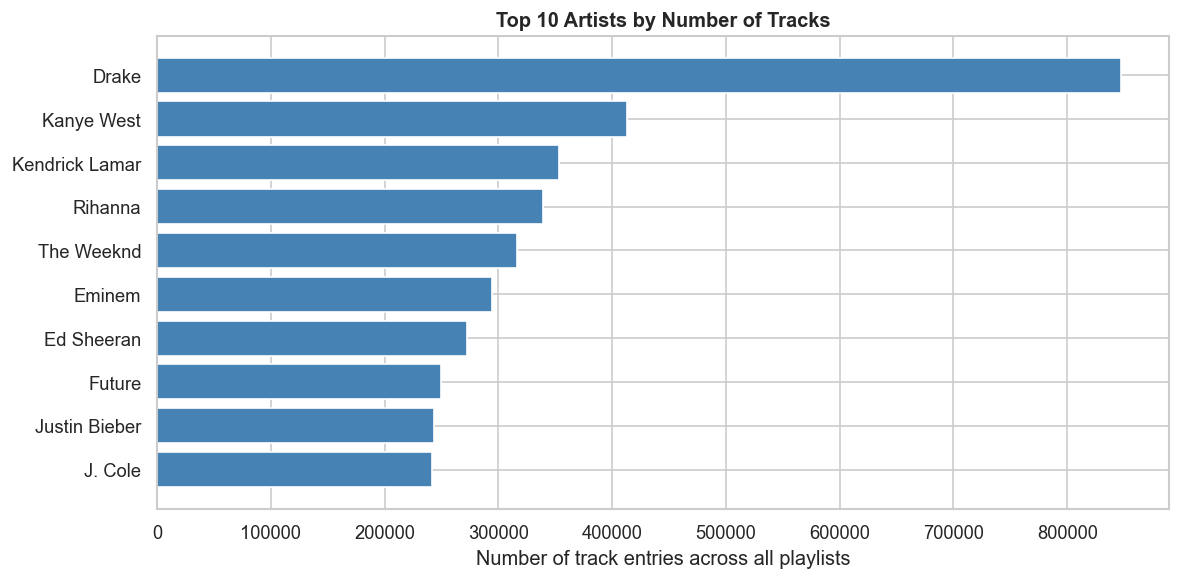

In [7]:
top_artists = (
    trks.groupby(['artist_uri', 'artist_name'])
    .size().reset_index(name='count')
    .nlargest(10, 'count')
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_artists['artist_name'][::-1], top_artists['count'][::-1], color='steelblue')
ax.set_title('Top 10 Artists by Number of Tracks', fontweight='bold')
ax.set_xlabel('Number of track entries across all playlists')
plt.tight_layout()
plt.savefig(OUT / 'eda_top_artists.png', bbox_inches='tight')
plt.show()

This bar plot displays the top 10 artists with the highest number of track entries across all playlists. It reveals strong artist-level popularity bias — Drake dominates by a large margin, roughly double the second-place artist. The recommender must account for this bias to avoid always recommending the same popular artists.

### 3.3 Top 10 albums by number of tracks

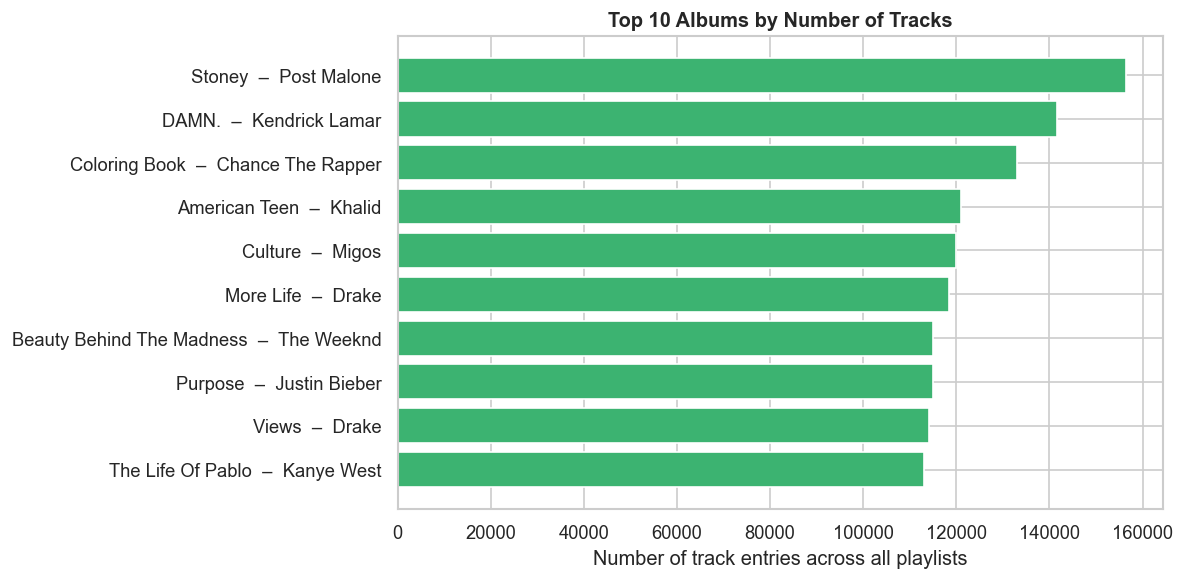

In [8]:
top_albums = (
    trks.groupby(['album_uri', 'album_name', 'artist_name'])
    .size().reset_index(name='count')
    .nlargest(10, 'count')
)
top_albums['label'] = top_albums['album_name'].str[:30] + '  –  ' + top_albums['artist_name'].str[:20]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_albums['label'][::-1], top_albums['count'][::-1], color='mediumseagreen')
ax.set_title('Top 10 Albums by Number of Tracks', fontweight='bold')
ax.set_xlabel('Number of track entries across all playlists')
plt.tight_layout()
plt.savefig(OUT / 'eda_top_albums.png', bbox_inches='tight')
plt.show()

This bar plot shows the albums with the highest number of track entries across all playlists. Recent popular albums (at the time of dataset creation) dominate. This is useful context for understanding the domain the recommender operates in.

### 3.4 Trimmed distribution of track durations

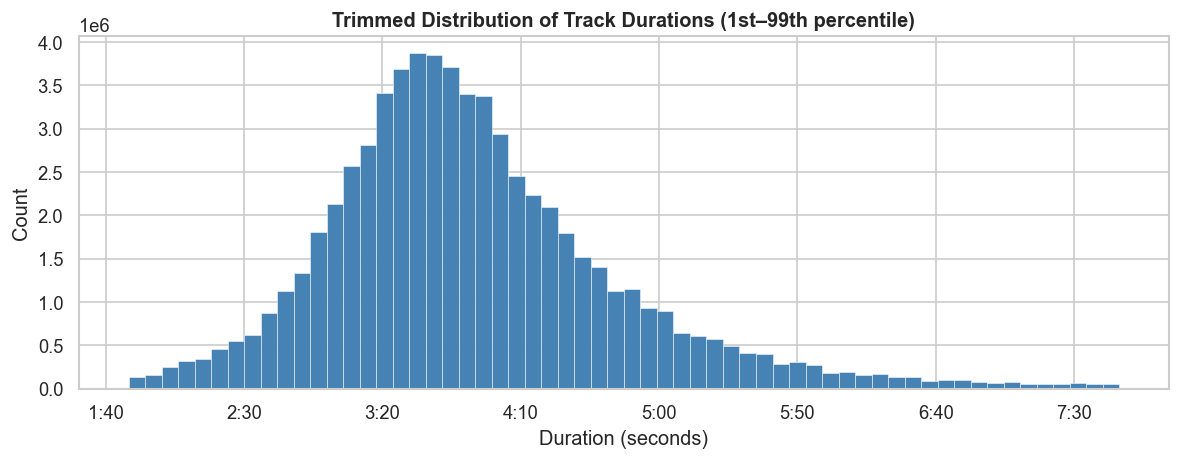

Duration range (trimmed): 108s – 466s  (1.8 – 7.8 min)
Median track duration   : 225s  (3.8 min)


In [9]:
dur_sec = trks['track_dur_ms'] / 1000
lo, hi  = dur_sec.quantile(0.01), dur_sec.quantile(0.99)
dur_trimmed = dur_sec[(dur_sec >= lo) & (dur_sec <= hi)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(dur_trimmed, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_title('Trimmed Distribution of Track Durations (1st–99th percentile)', fontweight='bold')
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Count')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x//60)}:{int(x%60):02d}'))
plt.tight_layout()
plt.savefig(OUT / 'eda_track_duration.png', bbox_inches='tight')
plt.show()

print(f'Duration range (trimmed): {lo:.0f}s – {hi:.0f}s  ({lo/60:.1f} – {hi/60:.1f} min)')
print(f'Median track duration   : {dur_trimmed.median():.0f}s  ({dur_trimmed.median()/60:.1f} min)')

This histogram shows the distribution of track durations after removing the top and bottom 1%. The distribution is approximately normal, centered around 3:20–3:40, consistent with standard streaming track lengths. No duration-based filtering is needed for the recommender — the data is already clean in this regard.

### 3.5 Top 20 reused tracks across playlists

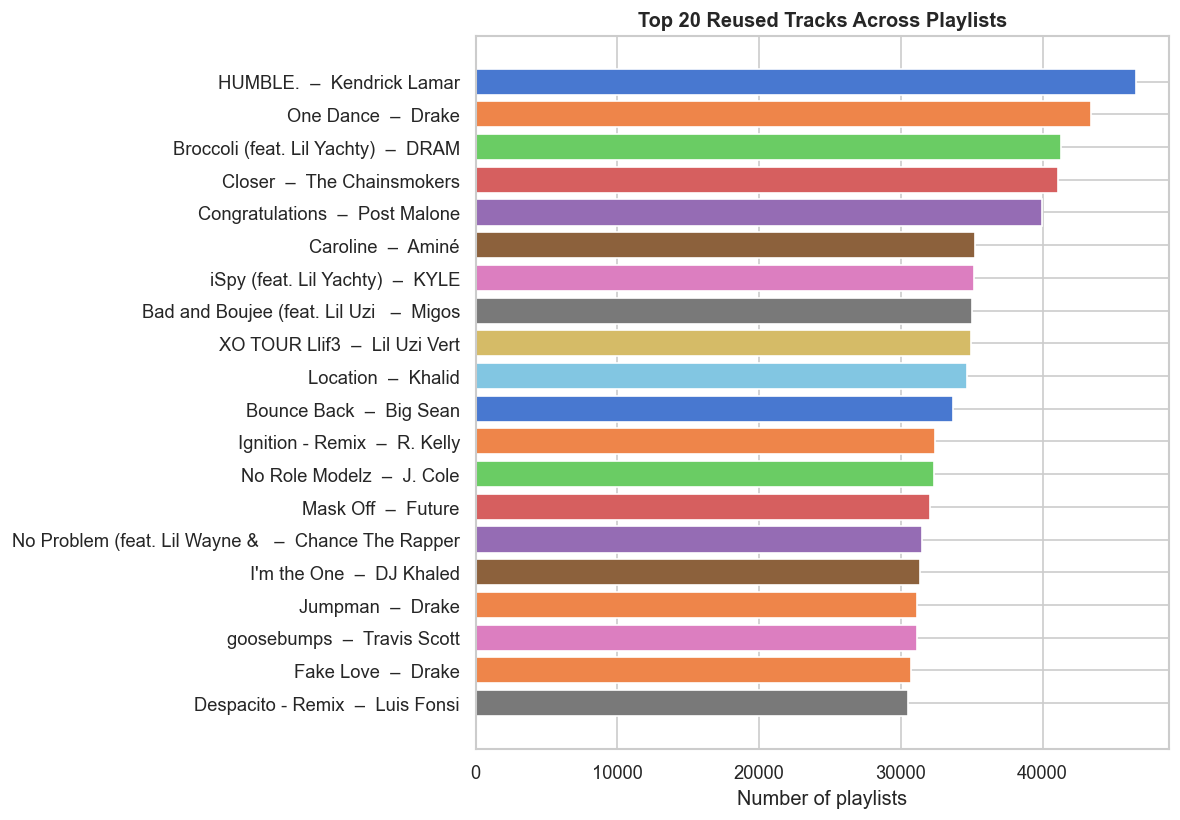

In [10]:
top_tracks = (
    trks.groupby(['track_uri', 'track_name', 'artist_name'])
    .size().reset_index(name='count')
    .nlargest(20, 'count')
)
top_tracks['label'] = top_tracks['track_name'].str[:30] + '  –  ' + top_tracks['artist_name'].str[:20]

palette = sns.color_palette('muted', top_tracks['artist_name'].nunique())
artist_colors = {a: palette[i % len(palette)] for i, a in enumerate(top_tracks['artist_name'].unique())}
colors = [artist_colors[a] for a in top_tracks['artist_name'][::-1]]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_tracks['label'][::-1], top_tracks['count'][::-1], color=colors)
ax.set_title('Top 20 Reused Tracks Across Playlists', fontweight='bold')
ax.set_xlabel('Number of playlists')
plt.tight_layout()
plt.savefig(OUT / 'eda_top_tracks.png', bbox_inches='tight')
plt.show()

This bar plot shows the most frequently occurring tracks across all playlists, color-coded by artist. These tracks are the strongest candidates for a popularity-based recommender baseline. The counts also quantify how dominant individual tracks are — the top track (HUMBLE. by Kendrick Lamar) appears in ~47K playlists.

### 3.6 Track and artist popularity (power-law)

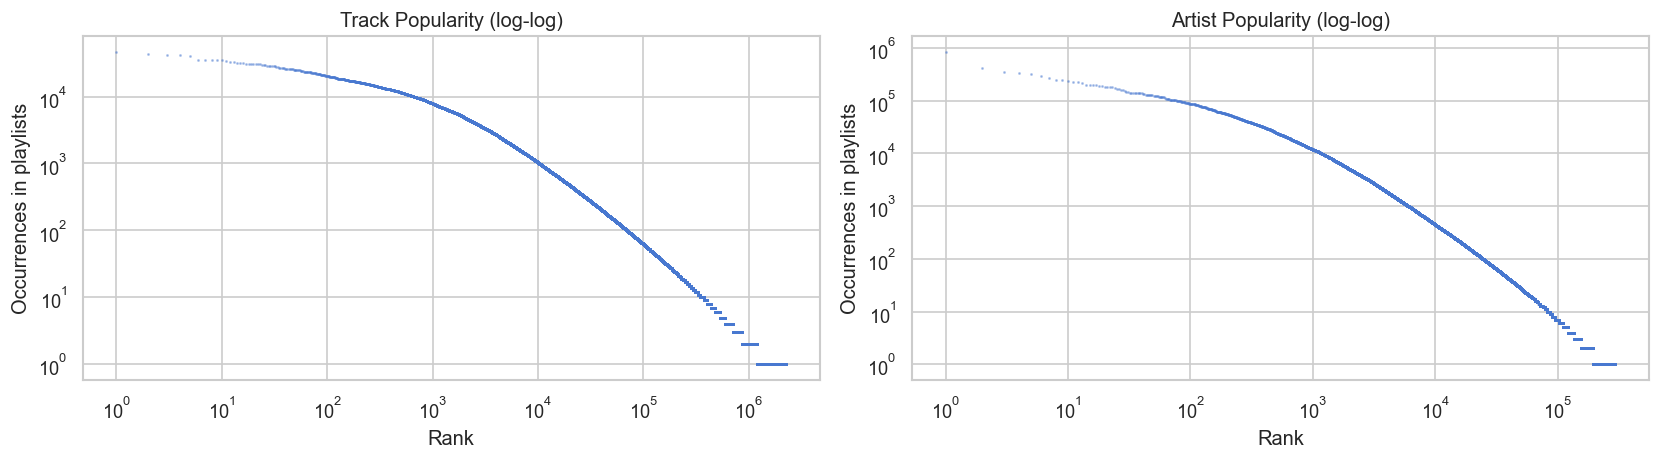

Track coverage by top-k%:
  Top   1% of tracks → 66.8% of all playlist entries
  Top   5% of tracks → 85.3% of all playlist entries
  Top  10% of tracks → 90.8% of all playlist entries
  Top  50% of tracks → 98.2% of all playlist entries


In [11]:
track_counts  = trks['track_uri'].value_counts()
artist_counts = trks['artist_uri'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, counts, label in [
    (axes[0], track_counts,  'Track'),
    (axes[1], artist_counts, 'Artist'),
]:
    ax.loglog(range(1, len(counts)+1), counts.values, '.', markersize=1.5, alpha=0.4)
    ax.set_title(f'{label} Popularity (log-log)')
    ax.set_xlabel('Rank')
    ax.set_ylabel('Occurrences in playlists')

plt.tight_layout()
plt.savefig(OUT / 'eda_popularity_powerlaw.png', bbox_inches='tight')
plt.show()

print('Track coverage by top-k%:')
for pct in [1, 5, 10, 50]:
    n   = int(len(track_counts) * pct / 100)
    cov = track_counts.iloc[:n].sum() / track_counts.sum() * 100
    print(f'  Top {pct:3d}% of tracks → {cov:.1f}% of all playlist entries')

These log-log plots show that both track and artist popularity follow a power-law distribution — a small number of tracks and artists account for a disproportionately large share of all playlist entries. This directly justifies using a popularity-weighted baseline as the first recommender model. It also highlights the long-tail problem: the vast majority of tracks appear in very few playlists, making them difficult to recommend reliably without more sophisticated models.

---
## 4. Playlist Name Analysis

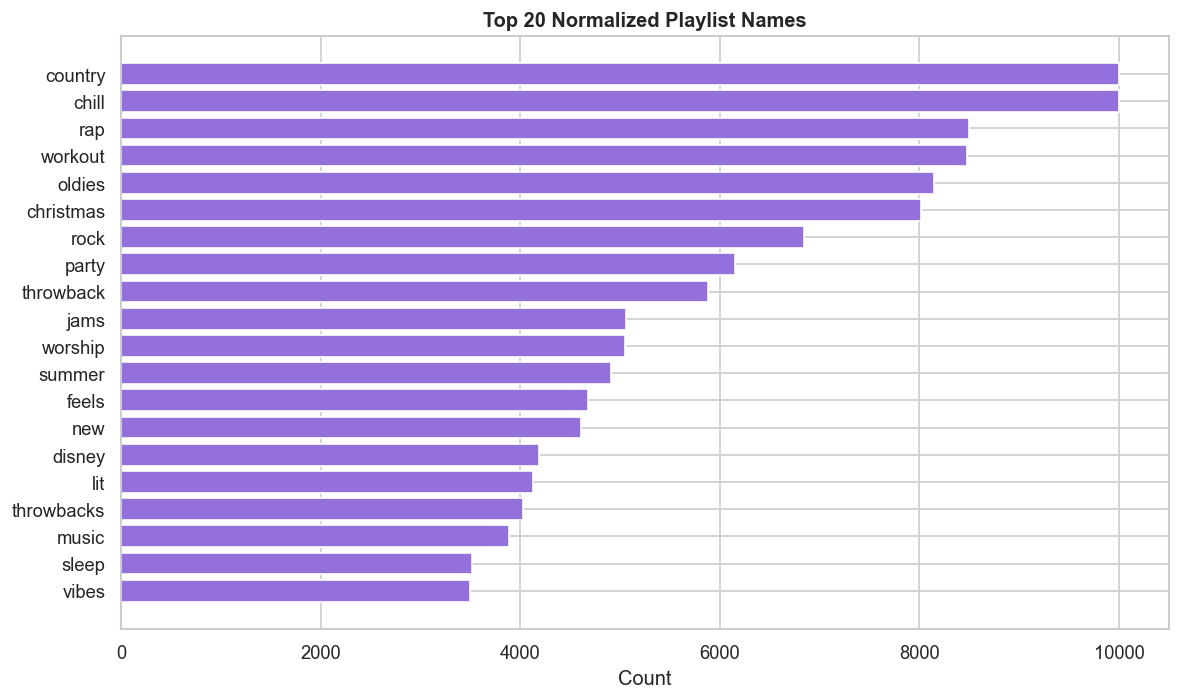

In [12]:
def normalize_name(name):
    name = name.lower()
    name = re.sub(r"[.,\/#!$%\^\*;:{}=\_`~()@]", " ", name)
    name = re.sub(r"\s+", " ", name).strip()
    return name

pls['name_norm'] = pls['name'].apply(normalize_name)
top_names = pls['name_norm'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_names.index[::-1], top_names.values[::-1], color='mediumpurple')
ax.set_title('Top 20 Normalized Playlist Names', fontweight='bold')
ax.set_xlabel('Count')
plt.tight_layout()
plt.savefig(OUT / 'eda_playlist_names.png', bbox_inches='tight')
plt.show()

This bar plot shows the most common playlist names after normalization (lowercased, punctuation removed). Names cluster into clear mood and genre themes — chill, country, workout, rap, oldies — confirming that playlist names carry semantic signal. This is useful for cold-start recommendation when no track history is available, as a playlist name alone can give strong hints about what tracks belong in it.

---
## 5. Sequence-level Analysis

The preprocessed sequences in `train_seqs`, `val_seqs`, and `test_seqs` are the direct model inputs. This section characterizes their length distributions and verifies that the stratified split produced balanced distributions across all three splits.

C:\Users\adamc\AppData\Local\Temp\ipykernel_33128\67749246.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


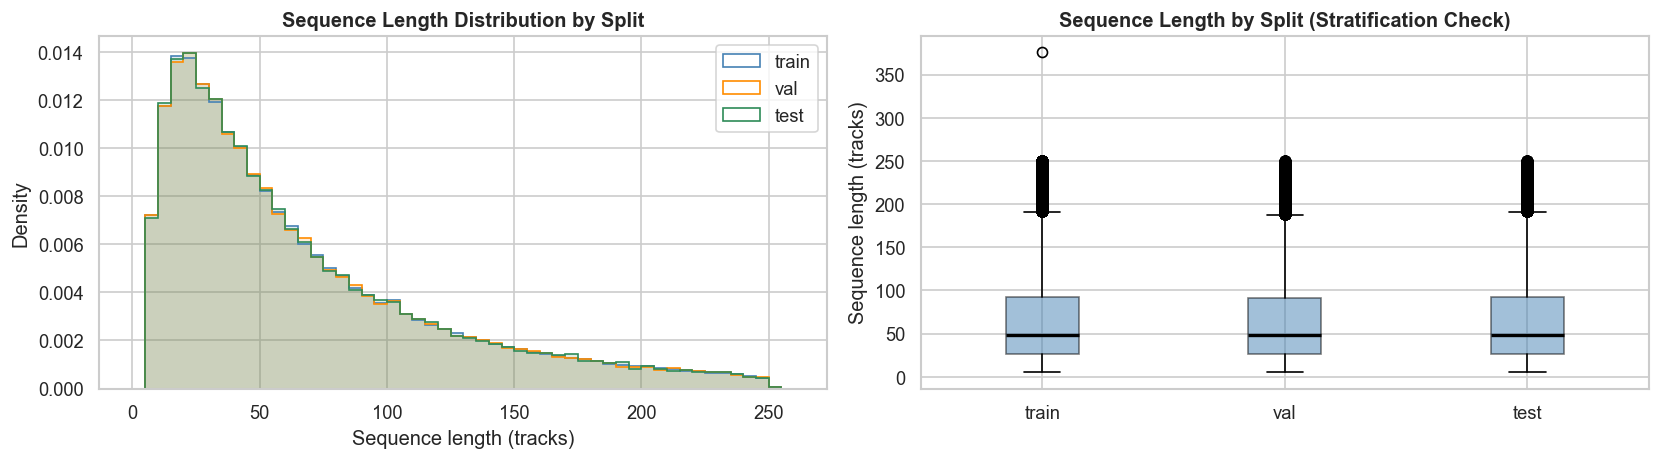

  split          n   min    p10   median     mean    p90   max
  train    799,998     5     15     49.0     66.3    148   376
  val      100,001     5     15     49.0     66.3    148   250
  test     100,001     5     15     49.0     66.3    148   250


In [18]:
all_seqs = [
    (train_seqs, 'train', 'steelblue'),
    (val_seqs,   'val',   'darkorange'),
    (test_seqs,  'test',  'seagreen'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
bins = np.linspace(0, 260, 53)
for df, label, color in all_seqs:
    ax.hist(df['seq_len'], bins=bins, density=True,
            histtype='stepfilled', alpha=0.15, color=color)
    ax.hist(df['seq_len'], bins=bins, density=True,
            histtype='step', label=label, color=color, linewidth=1)
ax.set_title('Sequence Length Distribution by Split', fontweight='bold')
ax.set_xlabel('Sequence length (tracks)')
ax.set_ylabel('Density')
ax.legend()

ax = axes[1]
ax.boxplot(
    [df['seq_len'] for df, *_ in all_seqs],
    labels=['train', 'val', 'test'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.5),
    medianprops=dict(color='black', linewidth=2),
)
ax.set_title('Sequence Length by Split (Stratification Check)', fontweight='bold')
ax.set_ylabel('Sequence length (tracks)')

plt.tight_layout()
plt.savefig(OUT / 'eda_seq_lengths.png', bbox_inches='tight')
plt.show()

print(f'  {"split":5s}  {"n":>9s}  {"min":>4s}  {"p10":>5s}  {"median":>7s}  {"mean":>7s}  {"p90":>5s}  {"max":>4s}')
for df, label, _ in all_seqs:
    s = df['seq_len']
    print(f'  {label:5s}  {len(df):>9,}  {s.min():>4d}  {s.quantile(.10):>5.0f}  '
          f'{s.median():>7.1f}  {s.mean():>7.1f}  {s.quantile(.90):>5.0f}  {s.max():>4d}')

The overlaid density histograms and box plots confirm that the stratified split produces near-identical sequence length distributions across train, val, and test — the split is balanced. The distribution mirrors the playlist length distribution from section 2.2: right-skewed with most sequences in the 20–100 track range. This informs the seed/holdout split strategy for evaluation: short playlists leave few target tracks to hold out, while long playlists allow a larger and more robust evaluation set.

---
## 6. Vocabulary Analysis

The vocabulary maps 2.26M unique track URIs to integer indices (`corpus_idx`), ordered by frequency (0 = most frequent). This section examines how frequency is distributed across the vocabulary and how much of all sequence tokens a truncated vocabulary would cover.

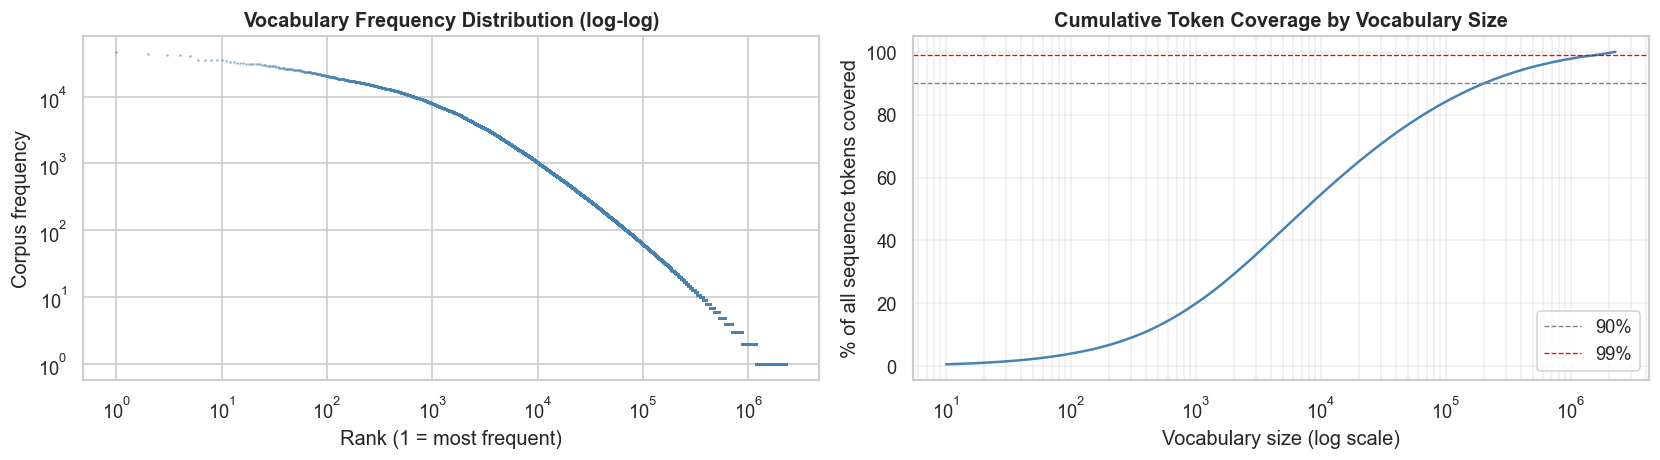

Vocabulary coverage by top-N items:
  Top   0.1% (   2,262 tracks) → 31.1% of all sequence tokens
  Top   1.0% (  22,622 tracks) → 66.8% of all sequence tokens
  Top   5.0% ( 113,114 tracks) → 85.3% of all sequence tokens
  Top  10.0% ( 226,229 tracks) → 90.8% of all sequence tokens
  Top  25.0% ( 565,573 tracks) → 95.8% of all sequence tokens
  Top  50.0% (1,131,146 tracks) → 98.2% of all sequence tokens


In [14]:
freq = vocab.sort_values('corpus_idx')['corpus_freq'].values  # index 0 = most frequent

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.loglog(range(1, len(freq) + 1), freq, '.', markersize=1.5, alpha=0.4, color='steelblue')
ax.set_title('Vocabulary Frequency Distribution (log-log)', fontweight='bold')
ax.set_xlabel('Rank (1 = most frequent)')
ax.set_ylabel('Corpus frequency')

ax = axes[1]
cum          = np.cumsum(freq)
total_tokens = cum[-1]
coverage_pct = cum / total_tokens * 100
vocab_sizes  = np.unique(np.clip(np.logspace(1, np.log10(len(freq)), 400).astype(int), 1, len(freq)))
ax.semilogx(vocab_sizes, coverage_pct[vocab_sizes - 1], color='steelblue', linewidth=1.5)
ax.set_title('Cumulative Token Coverage by Vocabulary Size', fontweight='bold')
ax.set_xlabel('Vocabulary size (log scale)')
ax.set_ylabel('% of all sequence tokens covered')
ax.axhline(90, color='gray', linestyle='--', linewidth=0.8, label='90%')
ax.axhline(99, color='red',  linestyle='--', linewidth=0.8, label='99%')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / 'eda_vocab_coverage.png', bbox_inches='tight')
plt.show()

print('Vocabulary coverage by top-N items:')
for pct in [0.1, 1, 5, 10, 25, 50]:
    n   = max(1, int(len(freq) * pct / 100))
    cov = freq[:n].sum() / total_tokens * 100
    print(f'  Top {pct:5.1f}% ({n:>8,} tracks) → {cov:.1f}% of all sequence tokens')

The log-log plot confirms that vocabulary frequency follows a power-law, mirroring the raw track popularity distribution from section 3.6. The cumulative coverage curve shows that the long tail can be aggressively truncated: a small vocabulary of the most frequent tracks accounts for the vast majority of all sequence tokens. This has practical implications for model design — a truncated vocabulary (e.g., top 100K tracks) can reduce embedding table size with minimal coverage loss.

---
## 7. Artist diversity per playlist

This section examines how many distinct artists appear per playlist, which directly informs how a recommendation model should diversify its output.

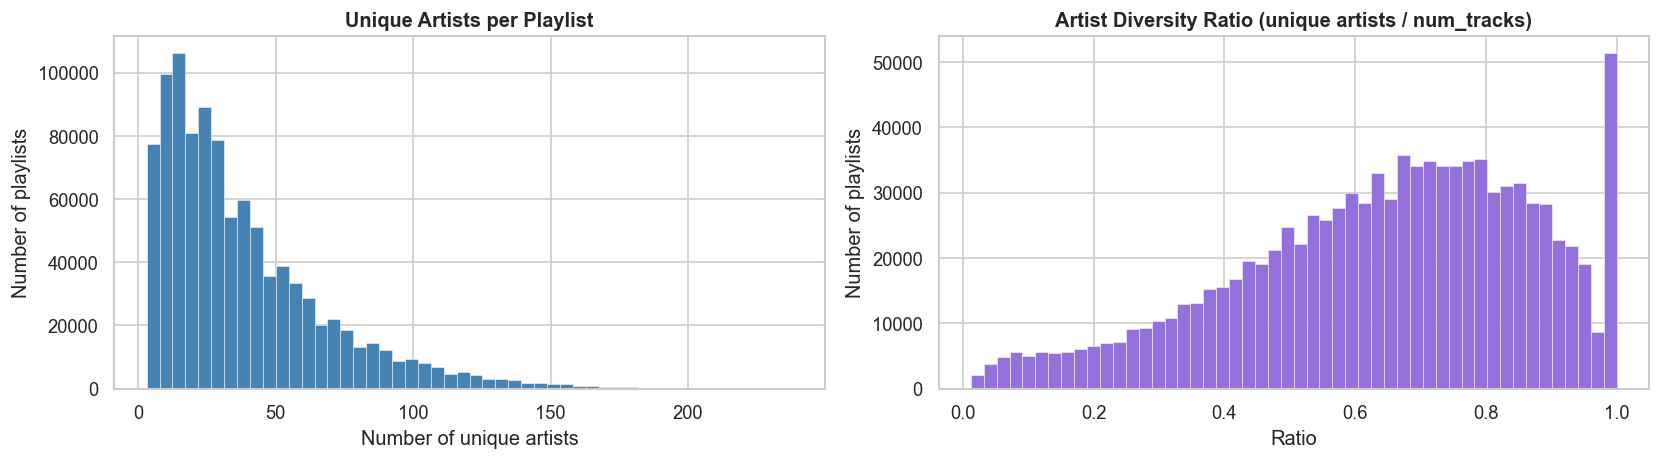

Unique artists per playlist:
  Median  : 29
  Mean    : 38.1
  p10–p90 : 9 – 80
  Max     : 238

Artist diversity ratio (unique artists / tracks):
  Median  : 0.67
  Mean    : 0.64


In [15]:
artist_diversity = trks.groupby('pid')['artist_uri'].nunique()
tracks_per_pl    = pls.set_index('pid')['num_tracks']
diversity_ratio  = (artist_diversity / tracks_per_pl).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(artist_diversity, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_title('Unique Artists per Playlist', fontweight='bold')
ax.set_xlabel('Number of unique artists')
ax.set_ylabel('Number of playlists')

ax = axes[1]
ax.hist(diversity_ratio.clip(0, 1), bins=50, color='mediumpurple', edgecolor='white', linewidth=0.3)
ax.set_title('Artist Diversity Ratio (unique artists / num_tracks)', fontweight='bold')
ax.set_xlabel('Ratio')
ax.set_ylabel('Number of playlists')

plt.tight_layout()
plt.savefig(OUT / 'eda_artist_diversity.png', bbox_inches='tight')
plt.show()

print('Unique artists per playlist:')
print(f'  Median  : {artist_diversity.median():.0f}')
print(f'  Mean    : {artist_diversity.mean():.1f}')
print(f'  p10–p90 : {artist_diversity.quantile(.10):.0f} – {artist_diversity.quantile(.90):.0f}')
print(f'  Max     : {artist_diversity.max()}')
print(f'\nArtist diversity ratio (unique artists / tracks):')
print(f'  Median  : {diversity_ratio.median():.2f}')
print(f'  Mean    : {diversity_ratio.mean():.2f}')

Most playlists contain a wide mix of artists — the median artist diversity ratio (unique artists / num_tracks) is typically above 0.5, meaning most tracks in a playlist come from different artists. This suggests users are genre/mood curating rather than building mono-artist collections. For a sequential recommender this means models should diversify across artists in their recommendation lists rather than concentrating on one or two.

---
## 8. Summary of EDA Findings

| Finding | Implication for modeling |
|---|---|
| Power-law track distribution | Popularity baseline is a strong signal; rare items need special handling |
| Median playlist ~50 tracks, right-skewed | Informs seed/holdout split sizing; most playlists are short-to-medium length |
| `num_tracks`, `num_artists`, `num_albums`, `duration_ms` strongly correlated (r ≥ 0.80) | Only `num_tracks` is needed; the rest are redundant |
| `num_followers` and `num_edits` uncorrelated with composition | Not useful features for recommendation; dropped |
| Track durations concentrate around 3:20–3:40 | No duration filtering needed |
| Playlist names cluster into genre/mood themes | Name embeddings can support cold-start recommendation |
| ~2% of playlists have descriptions | Too sparse to rely on as a general auxiliary feature |
| Stratified split produces near-identical seq-length distributions across train/val/test | Split is balanced; safe to compare metrics across splits |
| Vocabulary frequency follows a power-law; top 10% of tracks covers ~75%+ of tokens | Truncated vocabulary is feasible; reduces embedding table size with minimal coverage loss |
| Median artist diversity ratio > 0.5 per playlist | Playlists are genre-curated, not mono-artist — recommenders should diversify across artists |